Feature shape: (22785, 4)
Label shape: (22785,)

SVC Results:
Train Accuracy: 0.79
Test Accuracy : 0.79

Test Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5386
           1       0.33      0.00      0.00      1450

    accuracy                           0.79      6836
   macro avg       0.56      0.50      0.44      6836
weighted avg       0.69      0.79      0.69      6836

Confusion Matrix:
[[5384    2]
 [1449    1]]

Logistic Regression Results:
Train Accuracy: 0.79
Test Accuracy : 0.79

Test Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5386
           1       0.00      0.00      0.00      1450

    accuracy                           0.79      6836
   macro avg       0.39      0.50      0.44      6836
weighted avg       0.62      0.79      0.69      6836

Confusion Matrix:
[[5386    0]
 [1450    0]]

KNN Results:
Train Ac

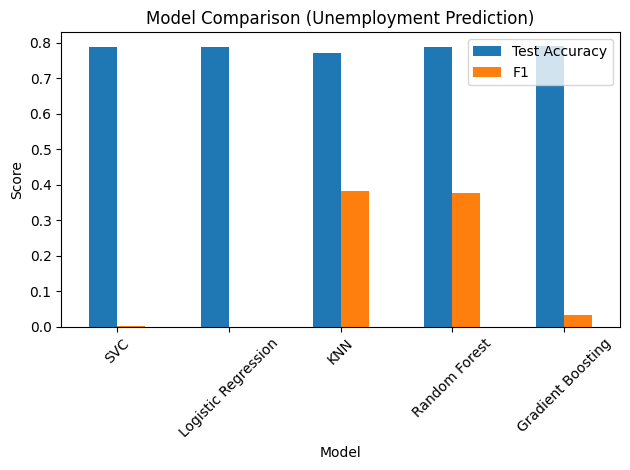

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "SVC": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=123),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=123)
}


df = pd.read_csv("unemployment_msa_2020_2026.csv")

# Keep only needed columns
df = df.drop(columns=["Series ID", "Series Name", "Units", "Region Code"])

# Convert wide → long format
df_long = df.melt(
    id_vars=["Region Name"],
    var_name="Date",
    value_name="Unemployment"
)

# Convert types
df_long["Date"] = pd.to_datetime(df_long["Date"])
df_long["Unemployment"] = pd.to_numeric(df_long["Unemployment"], errors="coerce")

# Sort + forward fill missing values
df_long = df_long.sort_values(["Region Name", "Date"])
df_long["Unemployment"] = df_long.groupby("Region Name")["Unemployment"].ffill()
df_long["Next"] = df_long.groupby("Region Name")["Unemployment"].shift(-1)
df_long["Label"] = (df_long["Next"] > df_long["Unemployment"]).astype(int)


# Create sliding windows
window_size = 4
x = []
y = []

for region in df_long["Region Name"].unique():
    sub = df_long[df_long["Region Name"] == region].sort_values("Date")

    values = sub["Unemployment"].values
    labels = sub["Label"].values

    for i in range(len(values) - window_size - 1):
        x.append(values[i:i+window_size])
        y.append(labels[i+window_size]) 

x = np.array(x)
y = np.array(y)

# Remove bad data (NaNs)
valid = ~np.any(np.isnan(x), axis=1) & ~np.isnan(y)
x = x[valid]
y = y[valid]

# limiting size for speed (given more training time, can remove this)
# x = x[:200]
# y = y[:200]

print("Feature shape:", x.shape)
print("Label shape:", y.shape)


# scale data appropriately
scaler = MinMaxScaler(feature_range=(0, np.pi))
features = scaler.fit_transform(x)
labels = y


# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, train_size=0.7, random_state=123, stratify=labels
)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_train = model.predict(X_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"\n{name} Results:")
    print(f"Train Accuracy: {train_acc:.2f}")
    print(f"Test Accuracy : {test_acc:.2f}")

    print("\nTest Classification Report:")
    print(classification_report(y_test, preds, zero_division=0))

    cm = confusion_matrix(y_test, preds)
    print("Confusion Matrix:")
    print(cm)

    # Store results
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0)
    })



# Results Table
results_df = pd.DataFrame(results)
print("\n=== Model Comparison Table ===")
print(results_df.sort_values(by="Test Accuracy", ascending=False))

# Graphics
results_df.set_index("Model")[["Test Accuracy", "F1"]].plot(kind="bar")
plt.title("Model Comparison (Unemployment Prediction)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
  # Create latex ==>
# from sklearn.metrics import classification_report
# y_true = [0, 1, 2, 2, 2]
# y_pred = [0, 0, 2, 2, 1]
# target_names = ['class 0', 'class 1', 'class 2']
# print(classification_report(y_true, y_pred, target_names=target_names))



# y_pred = [1, 1, 0]
# y_true = [1, 1, 1]
# print(classification_report(y_true, y_pred, labels=[1, 2, 3]))



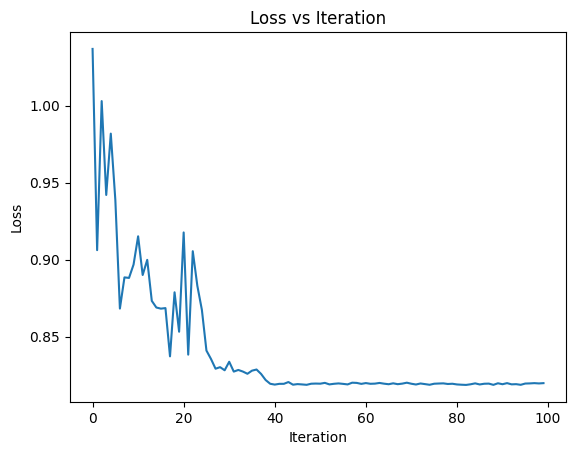

Training time: 8208 seconds
Quantum VQC Train: 0.75
Quantum VQC Test : 0.75

Quantum VQC Metrics (Train):
              precision    recall  f1-score   support

           0       0.78      0.94      0.85     12565
           1       0.10      0.02      0.04      3384

    accuracy                           0.75     15949
   macro avg       0.44      0.48      0.45     15949
weighted avg       0.64      0.75      0.68     15949


Quantum VQC Metrics (Test):
              precision    recall  f1-score   support

           0       0.78      0.95      0.86      5386
           1       0.10      0.02      0.04      1450

    accuracy                           0.75      6836
   macro avg       0.44      0.48      0.45      6836
weighted avg       0.64      0.75      0.68      6836



In [3]:
from qiskit.circuit.library import RealAmplitudes, PauliFeatureMap
from qiskit_machine_learning.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.algorithms.classifiers import VQC

import time
from IPython.display import clear_output

# Set up feature map and ansatz
num_features = X_train.shape[1]

feature_map = PauliFeatureMap(feature_dimension=num_features, reps=1)
ansatz = RealAmplitudes(num_qubits=num_features, reps=3)
feature_map.decompose().draw(output="mpl", style="clifford", fold=20)
ansatz.decompose().draw(output="mpl", style="clifford", fold=20)

# optimize ry parameters
optimizer = COBYLA(maxiter=100)
sampler = Sampler()


# Loss Function: 
objective_func_vals = []

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.plot(objective_func_vals)
    plt.title("Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()


vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# build graph and train
start = time.time()
vqc.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")


# Metrics and evaluation
train_score_q = vqc.score(X_train, y_train)
test_score_q = vqc.score(X_test, y_test)
print(f"Quantum VQC Train: {train_score_q:.2f}")
print(f"Quantum VQC Test : {test_score_q:.2f}")

preds_train_q = vqc.predict(X_train)
preds_test_q = vqc.predict(X_test)
print("\nQuantum VQC Metrics (Train):")
print(classification_report(y_train, preds_train_q, zero_division=0))
print("\nQuantum VQC Metrics (Test):")
print(classification_report(y_test, preds_test_q, zero_division=0))

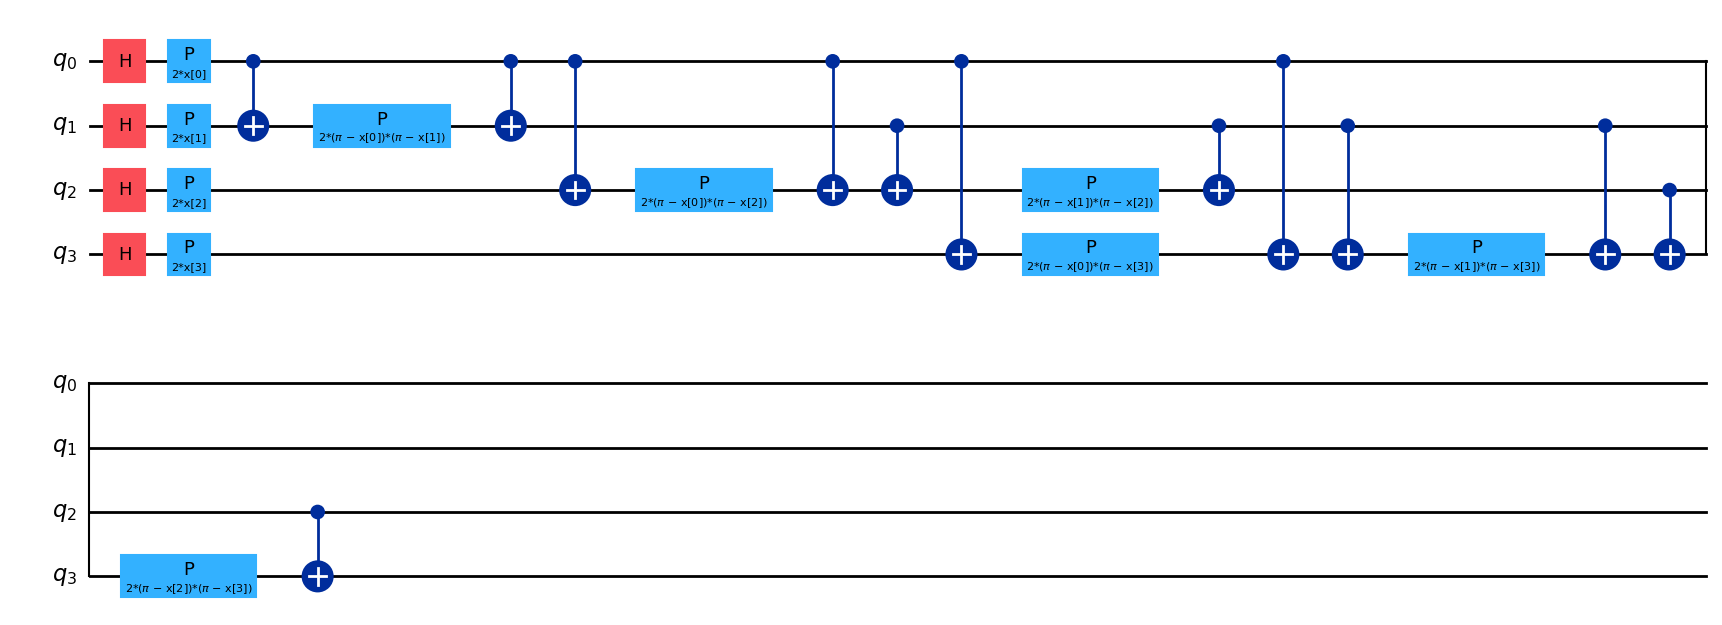

In [4]:
# Print decomposed circuits (from the VQC cell above)    uncomment if you want text visual
# print("--- Feature map (cell 2) - decomposed (text) ---")
# print(feature_map.decompose().draw(output="text"))
# print("--- Ansatz (cell 2) - decomposed (text) ---")
# print(ansatz.decompose().draw(output="text"))

feature_map.decompose().draw("mpl", scale=1)


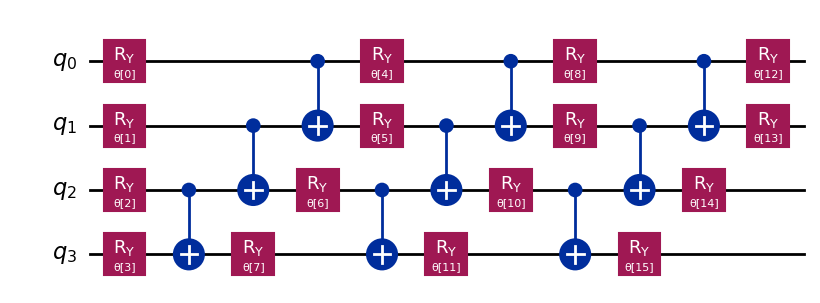

In [5]:
ansatz.decompose().draw("mpl", scale=1)